# 06 - Poredjenje modela

Ova sveska prikazuje uporedne rezultate modela `TF-IDF + Logistic Regression` i `LSTM`. Poredjenje je izdvojeno u posebnu svesku da bi rezultati bili jasno prikazani i graficki, u skladu sa propozicijama projekta.

In [4]:
from pathlib import Path
import os

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if not (ROOT / "reports").exists():
    ROOT = ROOT.parent

os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".matplotlib_cache"))
os.environ.setdefault("XDG_CACHE_HOME", str(ROOT / ".cache"))

import pandas as pd
import matplotlib.pyplot as plt


## Tabela rezultata

Za poredjenje koristimo metrike spam klase, jer je spam manjinska i vaznija klasa za ovaj problem. Vrednosti su preuzete iz finalnih evaluacija TF-IDF modela u svesci `03_finalna_evaluacija_tfidf.ipynb` i LSTM modela u svesci `05_finalna_evaluacija_lstm.ipynb`.

In [5]:
metric_columns = ["spam_precision", "spam_recall", "spam_f1"]
results = pd.DataFrame(
    [
        [0.99, 0.99, 0.99],
        [0.99, 0.96, 0.97],
        [0.98, 0.91, 0.95],
        [0.94, 0.90, 0.92],
    ],
    index=["TF-IDF - validacija", "TF-IDF - test", "LSTM - validacija", "LSTM - test"],
    columns=metric_columns,
).rename_axis("model_i_skup")

results

,spam_precision,spam_recall,spam_f1
model_i_skup,,,
TF-IDF - validacija,0.99,0.99,0.99
TF-IDF - test,0.99,0.96,0.97
LSTM - validacija,0.98,0.91,0.95
LSTM - test,0.94,0.90,0.92


## Graficki prikaz

Grafikon prikazuje `precision`, `recall` i `F1` za spam klasu na validacionom i test skupu. Visine stubova dolaze iz istoimenih kolona tabele `results`.

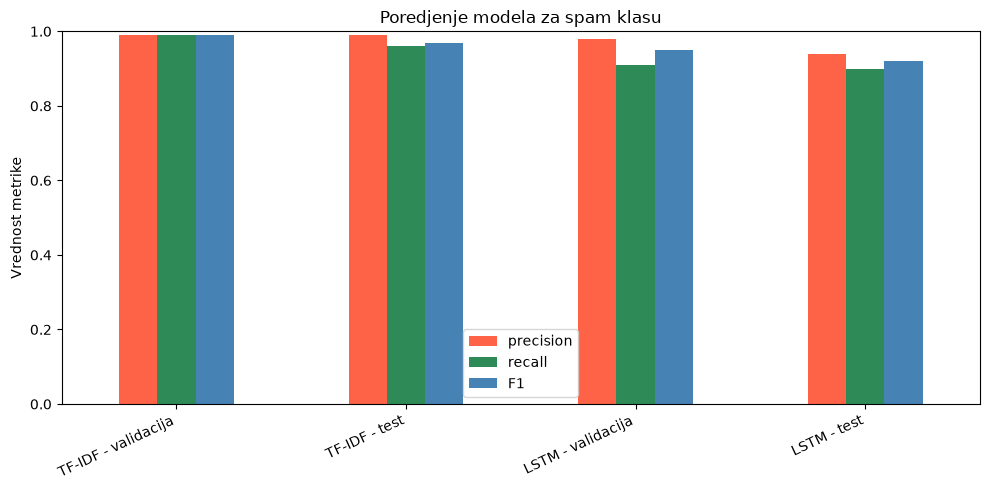

In [6]:
plot_data = results.copy()

ax = plot_data[metric_columns].plot(
    kind="bar",
    figsize=(10, 5),
    ylim=(0, 1),
    color=["tomato", "seagreen", "steelblue"],
)

ax.set_title("Poredjenje modela za spam klasu")
ax.set_ylabel("Vrednost metrike")
ax.set_xlabel("")
ax.legend(["precision", "recall", "F1"])
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## Zakljucak

Oba modela daju dobre rezultate na Ling-Spam skupu. TF-IDF + Logistic Regression postize najstabilniji rezultat i trenira se znatno brze. LSTM takodje uspesno detektuje spam mejlove, ali je osetljiviji na izbor hiperparametara i broj epoha.